<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Wrangling Lab**


Estimated time needed: **45** minutes


In this lab, you will perform data wrangling tasks to prepare raw data for analysis. Data wrangling involves cleaning, transforming, and organizing data into a structured format suitable for analysis. This lab focuses on tasks like identifying inconsistencies, encoding categorical variables, and feature transformation.


## Objectives


After completing this lab, you will be able to:


- Identify and remove inconsistent data entries.

- Encode categorical variables for analysis.

- Handle missing values using multiple imputation strategies.

- Apply feature scaling and transformation techniques.


#### Intsall the required libraries


In [1]:
!pip install pandas
!pip install matplotlib

## Tasks


#### Step 1: Import the necessary module.


### 1. Load the Dataset


<h5>1.1 Import necessary libraries and load the dataset.</h5>


Ensure the dataset is loaded correctly by displaying the first few rows.


In [55]:
# Import necessary libraries
import pandas as pd

# Load the Stack Overflow survey data
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(dataset_url)

# Display the first few rows
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                                   CodingActivities  \
0                                                             Hobby   
1  Hobby;Contribute to open-source projects;Other (please specify):   
2  Hobby;Contribute to open-source projects;Other (please specify):   
3                             

#### 2. Explore the Dataset


<h5>2.1 Summarize the dataset by displaying the column data types, counts, and missing values.</h5>


In [56]:
# Write your code here

print(df.info())

summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Null Count": df.notnull().sum(),
    "Missing Values": df.isna().sum()
})

summary

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB
None


,Data Type,Non-Null Count,Missing Values
ResponseId,int64,65437,0
MainBranch,str,65437,0
Age,str,65437,0
Employment,str,65437,0
RemoteWork,str,54806,10631
...,...,...,...
JobSatPoints_11,float64,29445,35992
SurveyLength,str,56182,9255
SurveyEase,str,56238,9199
ConvertedCompYearly,float64,23435,42002


<h5>2.2 Generate basic statistics for numerical columns.</h5>


In [60]:
# Write your code here

df.describe(include=['number'])

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


### 3. Identifying and Removing Inconsistencies


<h5>3.1 Identify inconsistent or irrelevant entries in specific columns (e.g., Country).</h5>


In [61]:
# Write your code here

print("Unique country names:", df['Country'].nunique())
print()
print("Counts of unique country names:", df['Country'].value_counts())
print()
print("Missing values in column country names:", df['Country'].isna().sum())

Unique country names: 185

Counts of unique country names: Country
United States of America                                11095
Germany                                                  4947
India                                                    4231
United Kingdom of Great Britain and Northern Ireland     3224
Ukraine                                                  2672
                                                        ...  
Haiti                                                       1
Nauru                                                       1
Chad                                                        1
Djibouti                                                    1
Solomon Islands                                             1
Name: count, Length: 185, dtype: int64

Missing values in column country names: 6507


In [63]:
# Eliminating blank spaces in the extremes of the country names (if any)

df['Country'] = df['Country'].str.strip()
print(df['Country'].nunique())

185


In [64]:
# Inspecting a country name to see inconsistencies (if any)

df[df['Country'].str.contains('Korea', na=False)]['Country'].value_counts()

Country
South Korea                              146
Republic of Korea                         57
North Korea                                3
Democratic People's Republic of Korea      2
Name: count, dtype: int64

In [65]:
# Standardizing the names of Korea's countries
# North Korea (Democratic People's Republic of Korea)
# South Korea (Republic of Korea)

df['Country'] = df['Country'].replace({
    'South Korea': 'South Korea',
    'Republic of Korea': 'South Korea',
    'North Korea': "North Korea",
    "Democratic People's Republic of Korea": "North Korea"
})

In [66]:
df[df['Country'].str.contains('Korea', na=False)]['Country'].value_counts()

Country
South Korea    203
North Korea      5
Name: count, dtype: int64

In [67]:
print(df['Country'].nunique())

183


In [69]:
pd.set_option('display.max_colwidth', None)
df[df['Country'].str.split().str.len() > 3]['Country'].unique()

<StringArray>
[                            'United States of America',
 'United Kingdom of Great Britain and Northern Ireland',
                         'Iran, Islamic Republic of...',
                          'Republic of North Macedonia',
                          'United Republic of Tanzania',
                 'Venezuela, Bolivarian Republic of...',
                     'Lao People's Democratic Republic',
                     'Democratic Republic of the Congo',
                            'Congo, Republic of the...',
                                'Saint Kitts and Nevis',
                   'Micronesia, Federated States of...']
Length: 11, dtype: str

In [70]:
countries = [
    'United States of America',
    'United Kingdom of Great Britain and Northern Ireland',
    'Iran, Islamic Republic of...',
    'Republic of North Macedonia',
    'United Republic of Tanzania',
    'Venezuela, Bolivarian Republic of...',
    "Lao People's Democratic Republic",
    'Democratic Republic of the Congo',
    'Congo, Republic of the...',
    'Saint Kitts and Nevis',
    'Micronesia, Federated States of...'
]

df[df['Country'].isin(countries)]['Country'].value_counts()

Country
United States of America                                11095
United Kingdom of Great Britain and Northern Ireland     3224
Iran, Islamic Republic of...                              411
Venezuela, Bolivarian Republic of...                       69
Republic of North Macedonia                                36
United Republic of Tanzania                                28
Congo, Republic of the...                                   8
Lao People's Democratic Republic                            4
Democratic Republic of the Congo                            3
Saint Kitts and Nevis                                       1
Micronesia, Federated States of...                          1
Name: count, dtype: int64

<h5>3.2 Standardize entries in columns like Country or EdLevel by mapping inconsistent values to a consistent format.</h5>


In [71]:
# Editing the country names more concisely. Checking that the two countries with "Congo" in the name are actually different.

df['Country'] = df['Country'].replace({
    'United States of America': 'United States',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'Iran, Islamic Republic of...': 'Iran',
    'Republic of North Macedonia': 'North Macedonia',
    'United Republic of Tanzania': 'Tanzania',
    'Venezuela, Bolivarian Republic of...': 'Venezuela',
    "Lao People's Democratic Republic": 'Laos',
    'Democratic Republic of the Congo': 'DR Congo',
    'Congo, Republic of the...': 'Congo Republic',
    'Saint Kitts and Nevis': 'Saint Kitts',
    'Micronesia, Federated States of...': 'Micronesia'
})

In [72]:
print(df['Country'].nunique())
print()
print(df['Country'].value_counts())

183

Country
United States      11095
Germany             4947
India               4231
United Kingdom      3224
Ukraine             2672
                   ...  
Haiti                  1
Nauru                  1
Chad                   1
Djibouti               1
Solomon Islands        1
Name: count, Length: 183, dtype: int64


In [73]:
countries2 = [
    'United States',
    'United Kingdom',
    'Iran',
    'North Macedonia',
    'Tanzania',
    'Venezuela',
    'Laos',
    'DR Congo',
    'Congo Republic',
    'Saint Kitts',
    'Micronesia'
]

df[df['Country'].isin(countries2)]['Country'].value_counts()

Country
United States      11095
United Kingdom      3224
Iran                 411
Venezuela             69
North Macedonia       36
Tanzania              28
Congo Republic         8
Laos                   4
DR Congo               3
Saint Kitts            1
Micronesia             1
Name: count, dtype: int64

### 4. Encoding Categorical Variables


<h5>4.1 Encode the Employment column using one-hot encoding.</h5>


In [74]:
## Write your code here


print("Unique Employment categories:", df['Employment'].nunique())
print()
print("Counts of Employment categories:", df['Employment'].value_counts())
print()
print("Missing values in column Employment:", df['Employment'].isna().sum())

Unique Employment categories: 110

Counts of Employment categories: Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                             

In [77]:
# There are too many Employment categories ~100, this will be hard to visualize. First, group them in broader categories in a new column 'Employment_Group'

In [75]:
def simplify_employment(x):

    first = x.split(';')[0]

    if first.startswith('Employed'):
        return 'Employed'

    elif first.startswith('Independent'):
        return 'Independent'

    elif first.startswith('Student'):
        return 'Student'

    elif 'but looking for work' in first:
        return 'Unemployed - Looking'

    elif 'and not looking for work' in first:
        return 'Unemployed - Not Looking'

    elif first.startswith('Retired'):
        return 'Retired'

    else:
        return 'Other'

df['Employment_Group'] = df['Employment'].apply(simplify_employment)

df['Employment_Group'].value_counts()

Employment_Group
Employed                    46436
Student                      8611
Independent                  5574
Unemployed - Looking         3040
Unemployed - Not Looking      705
Other                         546
Retired                       525
Name: count, dtype: int64

In [76]:
# Check what was grouped as "Other"

df[df['Employment_Group'] == 'Other']['Employment'].value_counts()

Employment
I prefer not to say    546
Name: count, dtype: int64

In [80]:
# Using this new column Employment_Group, proceed with the ONE-HOT encoding step. 
# Using Pandas: With pandas use pd.get_dummies() function to convert categorical columns into binary dummy variables.
# Using Scikit-learn: For machine learning pipelines, you can use the OneHotEncoder 

df_employment_encoded = pd.get_dummies(df['Employment_Group'], dtype=int)

In [82]:
df_employment_encoded.head(10)

,Employed,Independent,Other,Retired,Student,Unemployed - Looking,Unemployed - Not Looking
0,1,0,0,0,0,0,0
1,1,0,0,0,0,0,0
2,1,0,0,0,0,0,0
3,0,0,0,0,1,0,0
4,0,0,0,0,1,0,0
5,0,0,0,0,1,0,0
6,1,0,0,0,0,0,0
7,0,0,0,0,1,0,0
8,1,0,0,0,0,0,0
9,0,1,0,0,0,0,0


### 5. Handling Missing Values


<h5>5.1 Identify columns with the highest number of missing values.</h5>


In [83]:
## Write your code here
# Identify missing values for all columns in the dataset in descending order to see the column with the highest number of missing values

df.isna().sum().sort_values(ascending=False)

AINextMuch less integrated    64289
AINextLess integrated         63082
AINextNo change               52939
AINextMuch more integrated    51999
EmbeddedAdmired               48704
                              ...  
ResponseId                        0
Check                             0
MainBranch                        0
Employment                        0
Employment_Group                  0
Length: 115, dtype: int64

<h5>5.2 Impute missing values in numerical columns (e.g., `ConvertedCompYearly`) with the mean or median.</h5>


In [93]:
## Write your code here. Finding missing values

print("Missing values in ConvertedCompYearly column:",df['ConvertedCompYearly'].isna().sum())

Missing values in ConvertedCompYearly column: 42002


In [94]:
# Imputing missing values

df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(df['ConvertedCompYearly'].median())
print("Missing values in the normalized annual compensation column after imputation:",df['ConvertedCompYearly'].isna().sum())

Missing values in the normalized annual compensation column after imputation: 0


<h5>5.3 Impute missing values in categorical columns (e.g., `RemoteWork`) with the most frequent value.</h5>


In [84]:
## Write your code here

print("Missing values in Remote Work column:",df['RemoteWork'].isna().sum())

Missing values in Remote Work column: 10631


In [90]:
print("Counts of all categories in:", df['RemoteWork'].value_counts())
print()
print("The most frequent value in Remote Work:", df['RemoteWork'].mode())

Counts of all categories in: RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64

The most frequent value in Remote Work: 0    Hybrid (some remote, some in-person)
Name: RemoteWork, dtype: str


In [92]:
# Imputation with most frequent value

df['RemoteWork'] = df['RemoteWork'].fillna(df['RemoteWork'].mode()[0])
print("Counts of all categories in:", df['RemoteWork'].value_counts())
print()
print("Missing values in Remote Work column after imputation:",df['RemoteWork'].isna().sum())

Counts of all categories in: RemoteWork
Hybrid (some remote, some in-person)    33646
Remote                                  20831
In-person                               10960
Name: count, dtype: int64

Missing values in Remote Work column after imputation: 0


### 6. Feature Scaling and Transformation


<h5>6.1 Apply Min-Max Scaling to normalize the `ConvertedCompYearly` column.</h5>


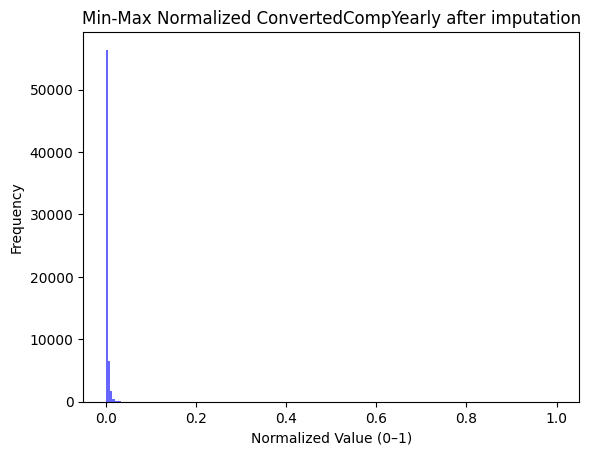

In [101]:
## Write your code here. Min-Max normalization & plot. Increasing the bins parameter to see the shape better

import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

plt.hist(
    MinMaxScaler().fit_transform(df[['ConvertedCompYearly']]),
    bins=200,
    color='blue',
    alpha=0.6
)
plt.title("Min-Max Normalized ConvertedCompYearly after imputation")
plt.xlabel("Normalized Value (0–1)")
plt.ylabel("Frequency")
plt.show()

In [99]:
# Create a new column with min-max transformed values

# Initialize scaler
minmax_scaler = MinMaxScaler()

# Create normalized column (0-1 range)
df['ConvertedCompYearly_MinMax'] = minmax_scaler.fit_transform(
    df[['ConvertedCompYearly']]
)

# Quick check
df[['ConvertedCompYearly', 'ConvertedCompYearly_MinMax']].head()

,ConvertedCompYearly,ConvertedCompYearly_MinMax
0,65000.0,0.003998
1,65000.0,0.003998
2,65000.0,0.003998
3,65000.0,0.003998
4,65000.0,0.003998


<h5>6.2 Log-transform the ConvertedCompYearly column to reduce skewness.</h5>


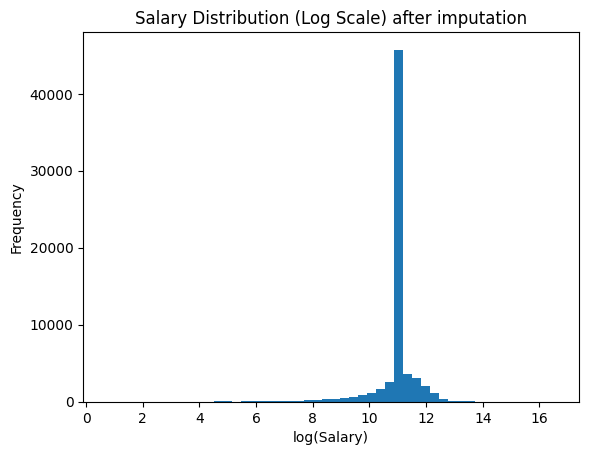

In [96]:
## Write your code here
# Log scale to transform data and deal with skewness, after imputation

import numpy as np
import matplotlib.pyplot as plt

plt.hist(np.log1p(df['ConvertedCompYearly']), bins=50)
plt.title("Salary Distribution (Log Scale) after imputation")
plt.xlabel("log(Salary)")
plt.ylabel("Frequency")
plt.show()

In [100]:
# Create a new column with log-transformed values

# Create new column
df['ConvertedCompYearly_Log'] = np.log1p(df['ConvertedCompYearly'])

# Quick check
df[['ConvertedCompYearly', 'ConvertedCompYearly_Log']].head()

,ConvertedCompYearly,ConvertedCompYearly_Log
0,65000.0,11.082158
1,65000.0,11.082158
2,65000.0,11.082158
3,65000.0,11.082158
4,65000.0,11.082158


### 7. Feature Engineering


<h5>7.1 Create a new column `ExperienceLevel` based on the `YearsCodePro` column:</h5>


In [103]:
# Check for missing values first

print("Missing values in YearsCodePro column:",df['YearsCodePro'].isna().sum())

Missing values in YearsCodePro column: 13827


In [104]:
# Get the most frequent value

print("Most frequent value in YearsCodePro:", df['YearsCodePro'].mode())

Most frequent value in YearsCodePro: 0    2
Name: YearsCodePro, dtype: str


In [107]:
## Write your code here

df['YearsCodePro'].value_counts().sort_values(ascending=False)

YearsCodePro
2                     4168
3                     4093
5                     3526
10                    3251
4                     3215
Less than 1 year      2856
6                     2843
1                     2639
8                     2549
7                     2517
12                    1777
15                    1635
20                    1549
9                     1493
11                    1312
13                    1127
14                    1082
25                     998
16                     946
18                     867
17                     814
30                     689
24                     632
19                     516
22                     492
23                     448
26                     426
27                     380
21                     380
28                     342
35                     285
29                     196
32                     194
40                     194
34                     169
38                     134
33             

In [108]:
# First convert the text categories into numbers, then CUT the now numeric column into ranges, and rename

df['ExperienceLevel'] = pd.cut(
    pd.to_numeric(
        df['YearsCodePro'].replace({
            'Less than 1 year': 0,
            'More than 50 years': 51
        }),
        errors='coerce'
    ),
    bins=[0, 1, 3, 5, 10, 20, 50, 100],
    labels=[
        '0–1 years',
        '1–3 years',
        '3–5 years',
        '5–10 years',
        '10–20 years',
        '20–50 years',
        '50+ years'
    ],
    include_lowest=True
)

In [109]:
df['ExperienceLevel'].value_counts().sort_index()

ExperienceLevel
0–1 years       5495
1–3 years       8261
3–5 years       6741
5–10 years     12653
10–20 years    11625
20–50 years     6785
50+ years         50
Name: count, dtype: int64

### Summary


In this lab, you:

- Explored the dataset to identify inconsistencies and missing values.

- Encoded categorical variables for analysis.

- Handled missing values using imputation techniques.

- Normalized and transformed numerical data to prepare it for analysis.

- Engineered a new feature to enhance data interpretation.


Copyright © IBM Corporation. All rights reserved.
